In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/raw/telco_customer_churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [10]:
df["TotalCharges"]

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, Length: 7043, dtype: object

In [11]:
.str.strip()

SyntaxError: invalid syntax (1371713117.py, line 1)

In [12]:
.eq("")

SyntaxError: invalid syntax (2342330130.py, line 1)

In [13]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [14]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [15]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [16]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [17]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [18]:
df["TotalCharges"].dtype

dtype('float64')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [20]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["New (0-12)", "Short-term (13-24)", "Medium-term (25-48)", "Long-term (49-72)"]
)

In [21]:
df[["tenure", "TenureGroup"]].head(10)

,tenure,TenureGroup
0,1,New (0-12)
1,34,Medium-term (25-48)
2,2,New (0-12)
3,45,Medium-term (25-48)
4,2,New (0-12)
5,8,New (0-12)
6,22,Short-term (13-24)
7,10,New (0-12)
8,28,Medium-term (25-48)
9,62,Long-term (49-72)


In [22]:
df["ChurnStatus"] = df["Churn"].map({"Yes": 1, "No": 0})

In [23]:
df[["Churn", "ChurnStatus"]].head(10)

,Churn,ChurnStatus
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1
5,Yes,1
6,No,0
7,No,0
8,Yes,1
9,No,0


In [24]:
churn_rate = df["ChurnStatus"].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 26.54%


In [25]:
total_customers = len(df)
churned_customers = df["ChurnStatus"].sum()
active_customers = total_customers - churned_customers

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Active Customers:", active_customers)

Total Customers: 7043
Churned Customers: 1869
Active Customers: 5174


In [26]:
contract_churn = (
    df.groupby("Contract")["ChurnStatus"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

contract_churn["ChurnRate"] = contract_churn["mean"] * 100

contract_churn

,Contract,count,sum,mean,ChurnRate
0,Month-to-month,3875,1655,0.427097,42.709677
1,One year,1473,166,0.112695,11.269518
2,Two year,1695,48,0.028319,2.831858


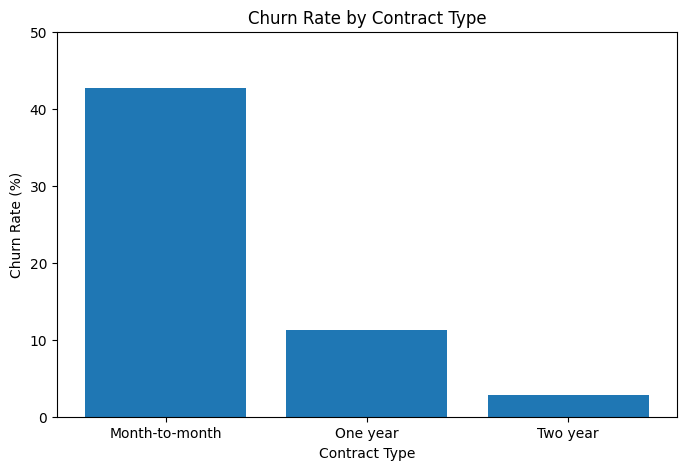

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    contract_churn["Contract"],
    contract_churn["ChurnRate"]
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.ylim(0, 50)

plt.show()

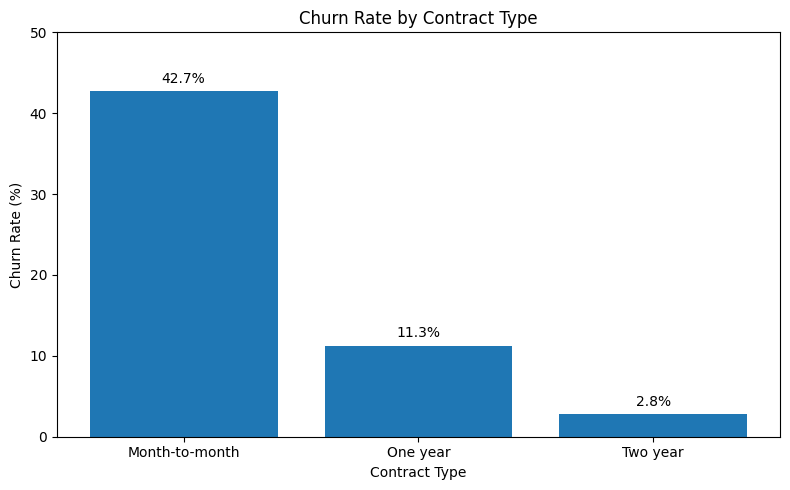

In [28]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    contract_churn["Contract"],
    contract_churn["ChurnRate"]
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Business Insight: Contract Type and Churn

Month-to-month customers have the highest churn rate at 42.7%, compared with 11.3% for one-year contracts and 2.8% for two-year contracts.

This indicates a strong association between shorter contract duration and customer churn. The company should consider targeted retention campaigns and incentives that encourage month-to-month customers to move to longer-term contracts.

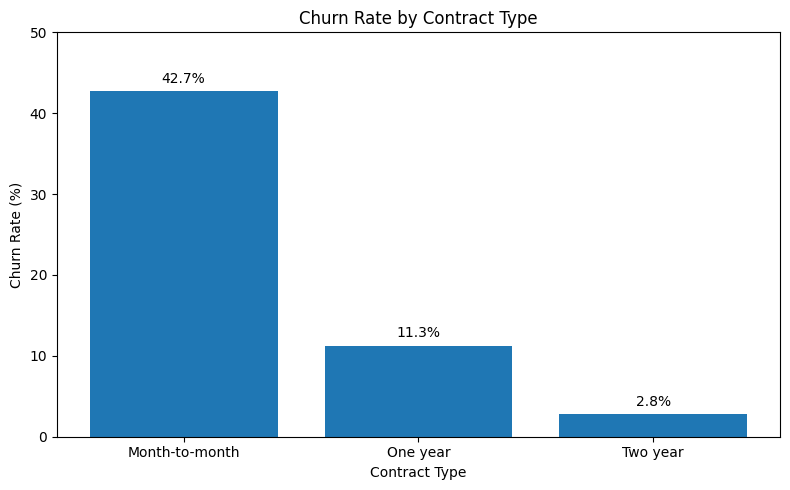

In [29]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    contract_churn["Contract"],
    contract_churn["ChurnRate"]
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [30]:
tenure_churn = (
    df.groupby("TenureGroup", observed=True)["ChurnStatus"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

tenure_churn["ChurnRate"] = tenure_churn["mean"] * 100

tenure_churn

,TenureGroup,count,sum,mean,ChurnRate
0,New (0-12),2186,1037,0.474382,47.438243
1,Short-term (13-24),1024,294,0.287109,28.710938
2,Medium-term (25-48),1594,325,0.203890,20.388959
3,Long-term (49-72),2239,213,0.095132,9.513176


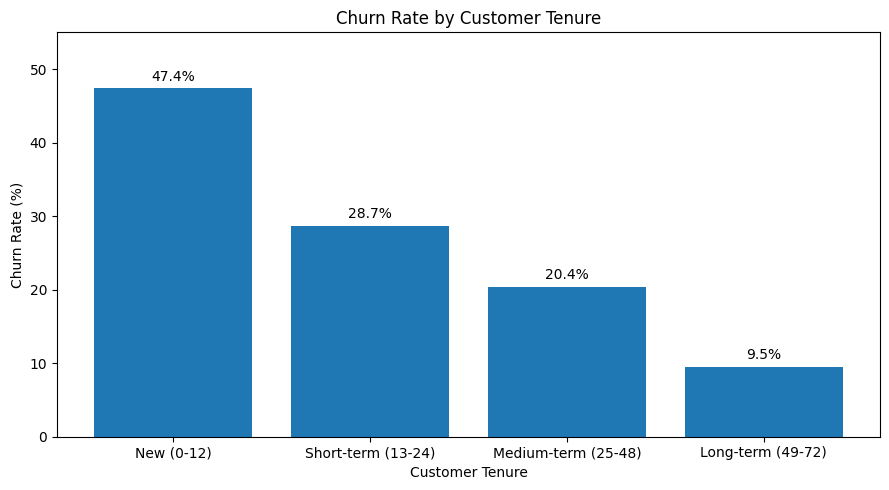

In [31]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    tenure_churn["TenureGroup"],
    tenure_churn["ChurnRate"]
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 55)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Business Insight: Customer Tenure and Churn

New customers have the highest observed churn rate at 47.4%, while long-term customers have the lowest at 9.5%.

This indicates a strong association between customer tenure and churn. The company should focus on improving onboarding and early-stage customer retention, particularly during the first 12 months.

In [32]:
internet_churn = (
    df.groupby("InternetService")["ChurnStatus"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

internet_churn["ChurnRate"] = internet_churn["mean"] * 100

internet_churn

,InternetService,count,sum,mean,ChurnRate
0,DSL,2421,459,0.189591,18.959108
1,Fiber optic,3096,1297,0.418928,41.892765
2,No,1526,113,0.074050,7.404980


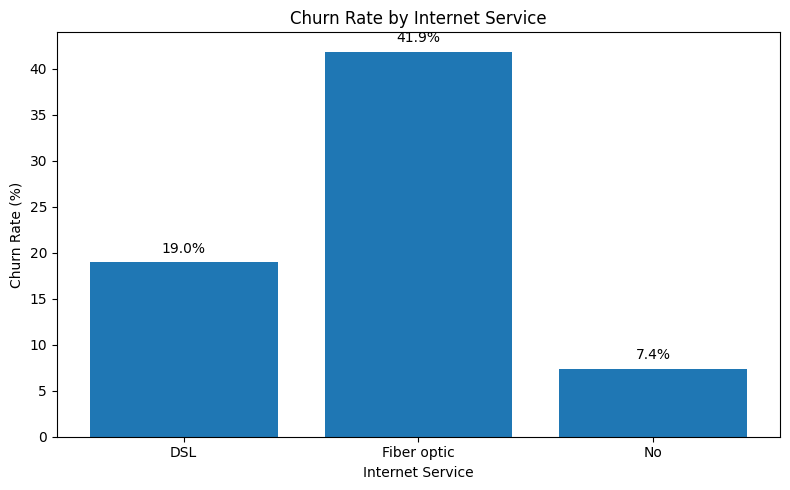

In [33]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    internet_churn["InternetService"],
    internet_churn["ChurnRate"]
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Business Insight: Internet Service and Churn

Customer churn varies across internet service categories. The analysis identifies the internet service segment with the highest observed churn rate.

This segment should be investigated further to understand whether pricing, service quality, customer experience, or other factors may be contributing to customer churn.

Further analysis is required before concluding that internet service itself causes churn.

In [34]:
internet_churn = (
    df.groupby("InternetService")["ChurnStatus"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

internet_churn["ChurnRate"] = internet_churn["mean"] * 100

internet_churn

,InternetService,count,sum,mean,ChurnRate
0,DSL,2421,459,0.189591,18.959108
1,Fiber optic,3096,1297,0.418928,41.892765
2,No,1526,113,0.074050,7.404980


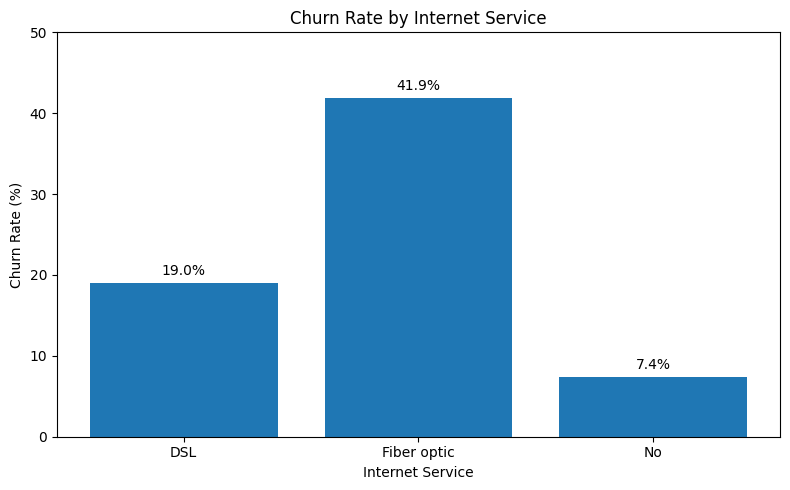

In [35]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    internet_churn["InternetService"],
    internet_churn["ChurnRate"]
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Business Insight: Internet Service and Churn

Fiber optic customers have the highest observed churn rate at 41.9%, compared with 19.0% for DSL customers and 7.4% for customers without internet service.

The company should investigate the fiber-optic customer segment further, particularly pricing, service quality, technical issues, and customer experience.

This analysis shows an association between internet service type and churn and does not establish that internet service itself causes customers to leave.

In [36]:
payment_churn = (
    df.groupby("PaymentMethod")["ChurnStatus"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

payment_churn["ChurnRate"] = payment_churn["mean"] * 100

payment_churn

,PaymentMethod,count,sum,mean,ChurnRate
0,Bank transfer (automatic),1544,258,0.167098,16.709845
1,Credit card (automatic),1522,232,0.152431,15.243101
2,Electronic check,2365,1071,0.452854,45.285412
3,Mailed check,1612,308,0.191067,19.106700


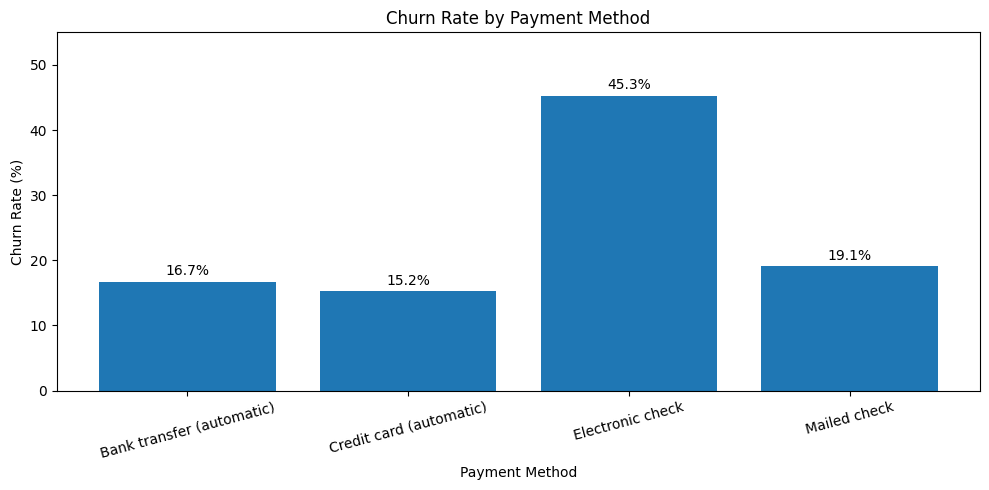

In [37]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    payment_churn["PaymentMethod"],
    payment_churn["ChurnRate"]
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 55)
plt.xticks(rotation=15)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Business Insight: Payment Method and Churn

Customers using electronic checks have the highest observed churn rate at 45.3%, compared with 15.2% for automatic credit card payments, 16.7% for automatic bank transfers, and 19.1% for mailed checks.

The company should investigate the electronic-check customer segment further and consider encouraging convenient automatic payment methods as part of its retention strategy.

The analysis identifies an association between payment method and churn and does not establish that payment method itself causes churn.

In [38]:
df["MonthlyChargeGroup"] = pd.qcut(
    df["MonthlyCharges"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [39]:
df[["MonthlyCharges", "MonthlyChargeGroup"]].head(10)

,MonthlyCharges,MonthlyChargeGroup
0,29.85,Low
1,56.95,Medium
2,53.85,Medium
3,42.30,Low
4,70.70,Medium
5,99.65,High
6,89.10,High
7,29.75,Low
8,104.80,High
9,56.15,Medium


In [40]:
df[["MonthlyCharges", "MonthlyChargeGroup"]].head(10)

,MonthlyCharges,MonthlyChargeGroup
0,29.85,Low
1,56.95,Medium
2,53.85,Medium
3,42.30,Low
4,70.70,Medium
5,99.65,High
6,89.10,High
7,29.75,Low
8,104.80,High
9,56.15,Medium


In [42]:
monthly_charge_churn = (
    df.groupby("MonthlyChargeGroup", observed=True)["ChurnStatus"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

monthly_charge_churn["ChurnRate"] = (
    monthly_charge_churn["mean"] * 100
)

monthly_charge_churn

,MonthlyChargeGroup,count,sum,mean,ChurnRate
0,Low,2351,373,0.158656,15.865589
1,Medium,2345,696,0.296802,29.680171
2,High,2347,800,0.340861,34.086067


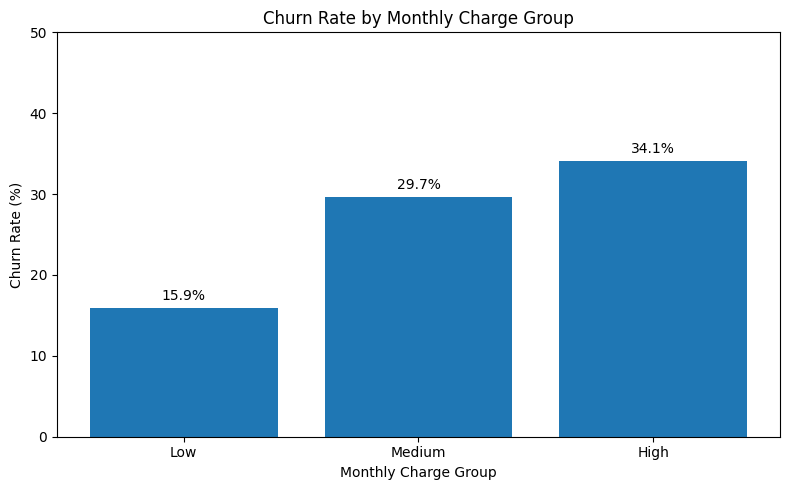

In [43]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    monthly_charge_churn["MonthlyChargeGroup"],
    monthly_charge_churn["ChurnRate"]
)

plt.title("Churn Rate by Monthly Charge Group")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [44]:
monthly_revenue_lost = df.loc[
    df["ChurnStatus"] == 1,
    "MonthlyCharges"
].sum()

print(f"Monthly Revenue Lost Due to Churn: ${monthly_revenue_lost:,.2f}")

Monthly Revenue Lost Due to Churn: $139,130.85


In [45]:
avg_churned_monthly_charge = df.loc[
    df["ChurnStatus"] == 1,
    "MonthlyCharges"
].mean()

avg_active_monthly_charge = df.loc[
    df["ChurnStatus"] == 0,
    "MonthlyCharges"
].mean()

print(f"Average Monthly Charge - Churned: ${avg_churned_monthly_charge:.2f}")
print(f"Average Monthly Charge - Active: ${avg_active_monthly_charge:.2f}")

Average Monthly Charge - Churned: $74.44
Average Monthly Charge - Active: $61.27


In [46]:
avg_churned_total = df.loc[
    df["ChurnStatus"] == 1,
    "TotalCharges"
].mean()

avg_active_total = df.loc[
    df["ChurnStatus"] == 0,
    "TotalCharges"
].mean()

print(f"Average Total Charges - Churned: ${avg_churned_total:.2f}")
print(f"Average Total Charges - Active: ${avg_active_total:.2f}")

Average Total Charges - Churned: $1531.80
Average Total Charges - Active: $2549.91


In [47]:
monthly_revenue_lost = df.loc[
    df["ChurnStatus"] == 1,
    "MonthlyCharges"
].sum()

print(f"Monthly Revenue Lost Due to Churn: ${monthly_revenue_lost:,.2f}")

Monthly Revenue Lost Due to Churn: $139,130.85


In [48]:
avg_churned_monthly_charge = df.loc[
    df["ChurnStatus"] == 1,
    "MonthlyCharges"
].mean()

avg_active_monthly_charge = df.loc[
    df["ChurnStatus"] == 0,
    "MonthlyCharges"
].mean()

print(f"Average Monthly Charge - Churned: ${avg_churned_monthly_charge:.2f}")
print(f"Average Monthly Charge - Active: ${avg_active_monthly_charge:.2f}")

Average Monthly Charge - Churned: $74.44
Average Monthly Charge - Active: $61.27


In [49]:
df["EstimatedCLV"] = df["MonthlyCharges"] * df["tenure"]

In [50]:
df[["tenure", "MonthlyCharges", "EstimatedCLV", "Churn"]].head(10)

,tenure,MonthlyCharges,EstimatedCLV,Churn
0,1,29.85,29.85,No
1,34,56.95,1936.30,No
2,2,53.85,107.70,Yes
3,45,42.30,1903.50,No
4,2,70.70,141.40,Yes
5,8,99.65,797.20,Yes
6,22,89.10,1960.20,No
7,10,29.75,297.50,No
8,28,104.80,2934.40,Yes
9,62,56.15,3481.30,No


In [51]:
clv_summary = (
    df.groupby("ChurnStatus")["EstimatedCLV"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

clv_summary

,ChurnStatus,count,mean,median
0,0,5174,2549.770883,1687.125
1,1,1869,1531.608828,700.000


# Final EDA Business Insights

## Key Findings

### 1. Overall Churn
The overall customer churn rate is 26.54%, with 1,869 out of 7,043 customers having churned.

### 2. Contract Type
Month-to-month customers have the highest observed churn rate at 42.71%, compared with 11.27% for one-year contracts and 2.83% for two-year contracts.

### 3. Customer Tenure
New customers (0–12 months) have the highest observed churn rate at 47.44%, while long-term customers (49–72 months) have a churn rate of 9.51%.

### 4. Internet Service
Fiber optic customers have the highest observed churn rate at 41.89%, compared with 18.96% for DSL customers and 7.40% for customers without internet service.

### 5. Payment Method
Customers using electronic checks have the highest observed churn rate at 45.29%, compared with 15.24% for automatic credit-card payments.

### 6. Revenue Impact
Churned customers represent approximately $139,130.85 in monthly charges associated with customers who have left the company.

### 7. Monthly Charges
Churned customers have a higher average monthly charge ($74.44) than active customers ($61.27), indicating that the company may be losing relatively higher-paying customers.

### 8. Estimated Customer Lifetime Value
Active customers have an average estimated CLV of $2,549.77, compared with $1,531.61 for churned customers.

## Business Recommendations

1. Focus retention campaigns on new customers, particularly during their first 12 months.
2. Encourage month-to-month customers to move to longer-term contracts through suitable incentives.
3. Investigate the high churn observed among fiber optic customers, including pricing, service quality and customer experience.
4. Investigate the electronic-check customer segment and consider promoting convenient automatic payment options.
5. Prioritize retention of higher-paying customers because churned customers have higher average monthly charges.
6. Develop targeted customer-retention strategies based on customer tenure, contract type, service type and payment behavior.

## Important Analytical Note

These findings identify associations between customer characteristics and churn. They do not establish that any individual factor directly causes customers to churn.